<a href="https://colab.research.google.com/github/KavyaPatel03/lending-club/blob/main/Lending_club.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ***UNDERSTANDING THE DATA***

In [ ]:
loan = pd.read_csv('loan_csv.csv')

In [ ]:
loan.shape

(39717, 111)

In [ ]:
loan.info(verbose = True,show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 111 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    id                              39717 non-null  int64  
 1    member_id                       39717 non-null  int64  
 2    loan_amnt                       39717 non-null  int64  
 3    funded_amnt                     39717 non-null  int64  
 4    funded_amnt_inv                 39717 non-null  float64
 5    term                            39717 non-null  object 
 6    int_rate                        39717 non-null  object 
 7    installment                     39717 non-null  float64
 8    grade                           39717 non-null  object 
 9    sub_grade                       39717 non-null  object 
 10   emp_title                       37258 non-null  object 
 11   emp_length                      38642 non-null  object 
 12   home_ownership  

In [ ]:
loan.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
5,1075269,1311441,5000,5000,5000.0,36 months,7.90%,156.46,A,A4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6,1069639,1304742,7000,7000,7000.0,60 months,15.96%,170.08,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
7,1072053,1288686,3000,3000,3000.0,36 months,18.64%,109.43,E,E1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
8,1071795,1306957,5600,5600,5600.0,60 months,21.28%,152.39,F,F2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
9,1071570,1306721,5375,5375,5350.0,60 months,12.69%,121.45,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [ ]:
loan.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

#***DATA*** ***CLEANING***

In [ ]:
loan.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
tax_liens,39
tot_hi_cred_lim,39717
total_bal_ex_mort,39717
total_bc_limit,39717


Finding the total number of null cells in each column

In [ ]:
round(loan.isnull().sum()/len(loan.index),2)*100

,0
id,0.0
member_id,0.0
loan_amnt,0.0
funded_amnt,0.0
funded_amnt_inv,0.0
...,...
tax_liens,0.0
tot_hi_cred_lim,100.0
total_bal_ex_mort,100.0
total_bc_limit,100.0


Changing the total number of null cells into percentage of null values present.

In [ ]:
missing_columns = loan.columns[100*(loan.isnull().sum()/len(loan.index)) > 90]
print(missing_columns)

Index(['mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint',
       'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
       'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd',
       'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
       'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
       'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
 

Shows the columns that have null values more than 90%

In [ ]:
loan = loan.drop(missing_columns, axis=1)
print(loan.shape)

(39717, 55)


Checking the total numbers of columns

In [ ]:
100*(loan.isnull().sum()/len(loan.index))

,0
id,0.000000
member_id,0.000000
loan_amnt,0.000000
funded_amnt,0.000000
funded_amnt_inv,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000


Checking the percentage of null values in the remaining cells

In [ ]:
loan = loan.drop(['desc', 'mths_since_last_delinq'], axis=1, errors='ignore')

Droping the columns that have more null values than 40%

In [ ]:
100*(loan.isnull().sum()/len(loan.index))

,0
id,0.000000
member_id,0.000000
loan_amnt,0.000000
funded_amnt,0.000000
funded_amnt_inv,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000


In [ ]:
loan.isnull().sum(axis=1)

,0
0,1
1,0
2,1
3,0
4,0
...,...
39712,4
39713,4
39714,5
39715,5


Null values in each rows

In [ ]:
len(loan[loan.isnull().sum(axis=1) > 5].index)

0

Finding if any row has null values more than 5 cells

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [ ]:
loan['int_rate_1'] = pd.to_numeric(loan['int_rate'].str.rstrip('%'))

Removing the % sign from interest rate and changing the data type to numeric

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [ ]:
loan['emp_length']

,emp_length
0,10+ years
1,< 1 year
2,10+ years
3,10+ years
4,1 year
...,...
39712,4 years
39713,3 years
39714,< 1 year
39715,< 1 year


In [ ]:
loan['emp_length_1'] = loan['emp_length'].str.extract(r'(\d+)').astype(pd.Int64Dtype())

Categorizing employee length in exact years

In [ ]:
loan['emp_length_1'].value_counts()

,count
emp_length_1,
10,8879
1,7823
2,4388
3,4095
4,3436
5,3282
6,2229
7,1773
8,1479


In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 55 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

# ***DATA*** ***ANALYSIS***

In [ ]:
behaviour_var =  [
  "delinq_2yrs",
  "earliest_cr_line",
  "inq_last_6mths",
  "open_acc",
  "pub_rec",
  "revol_bal",
  "revol_util",
  "total_acc",
  "out_prncp",
  "out_prncp_inv",
  "total_pymnt",
  "total_pymnt_inv",
  "total_rec_prncp",
  "total_rec_int",
  "total_rec_late_fee",
  "recoveries",
  "collection_recovery_fee",
  "last_pymnt_d",
  "last_pymnt_amnt",
  "last_credit_pull_d",
  "application_type"]
behaviour_var

['delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'application_type']

In [ ]:
df = loan.drop(behaviour_var,axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [ ]:
df = df.drop(['title', 'url', 'zip_code', 'addr_state'], axis=1)

In [ ]:
df['loan_status_1'] = df['loan_status'].astype('category')
df['loan_status_1'].value_counts()

,count
loan_status_1,
Fully Paid,32950
Charged Off,5627
Current,1140


In [ ]:
df = df[df['loan_status'] != 'Current']

df['loan_status_1'] = df['loan_status'].replace({'Fully Paid': 0,'Charged Off': 1})

df['loan_status_1'].value_counts()

,count
loan_status_1,
0,32950
1,5627


Droping the category 'Current' and replacing the category Fully paid with '0' and Charged off with '1'

# ***UNIVARIATE*** ***ANALYSIS***

In [ ]:
round(np.mean(df['loan_status_1']),5)*100

np.float64(14.585999999999999)

Fiding average percentage of defaulters.

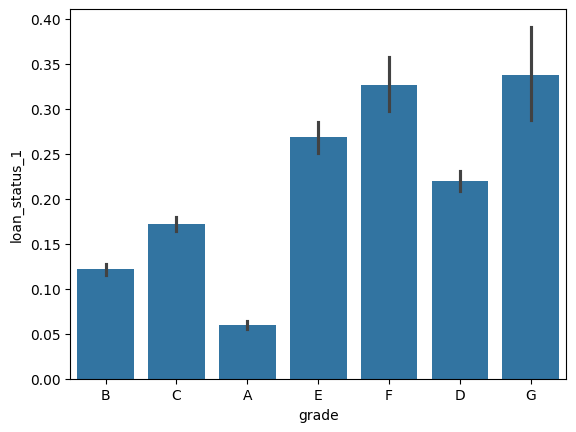

In [ ]:
sns.barplot(x='grade', y='loan_status_1', data = df)
plt.show()

This chart shows that what is the average % of defaulters in each grade. According to this chart the most defaulters are from grade G and F.

In [ ]:
def plot_cat(cat_var):
  sns.barplot(x = cat_var, y = 'loan_status_1',data = df)
  plt.show()

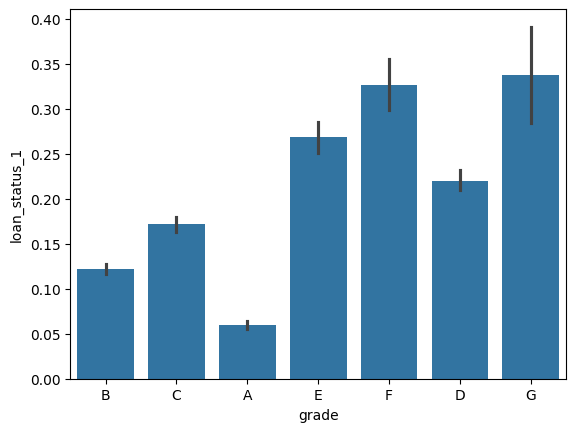

In [ ]:
plot_cat('grade')

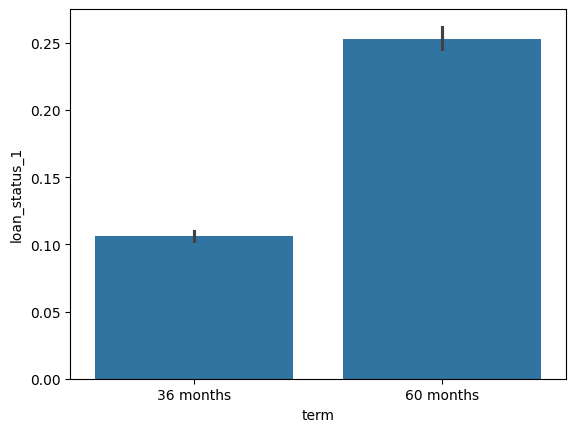

In [ ]:
plot_cat('term')

This shows the % of defaulters according to the term of loan they are taking.We should be careful while giving the loan to the people asking for loan form 60 months.

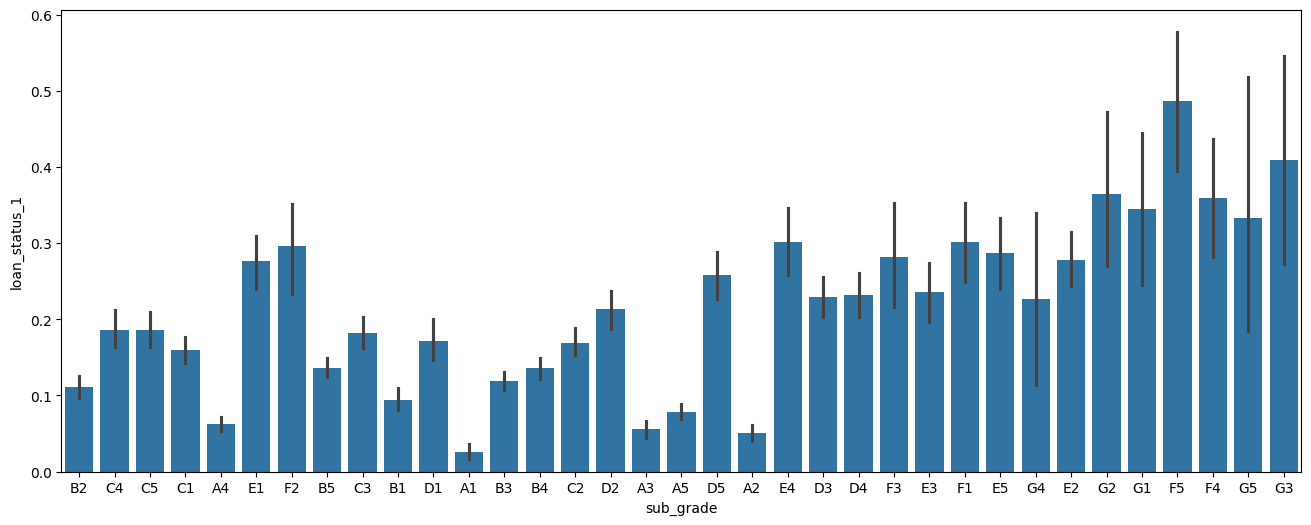

In [ ]:
plt.figure(figsize=(16,6))
plot_cat('sub_grade')

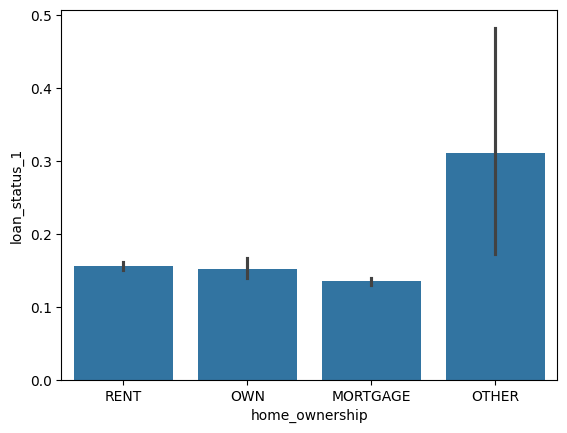

In [ ]:
plot_cat('home_ownership')

This chart shoes that what is the percentage of defaulters according to the living condition of the loan borrower.The people who has other living condition has the highest rate of defaulters.

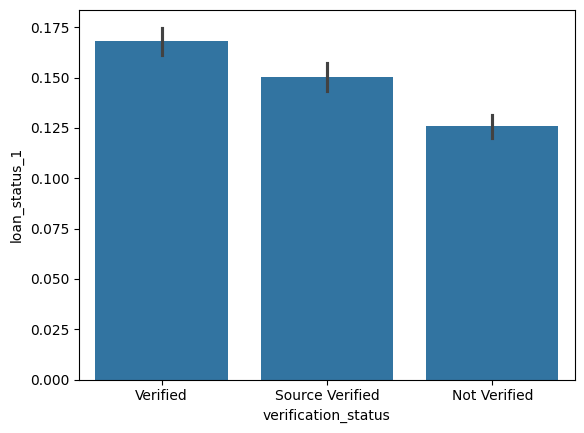

In [ ]:
plot_cat('verification_status')

This chart shows that which type of people are gettig defaulters. Verified people are more defaulters and hence it is an advice to verify the loan takers with more precisally.

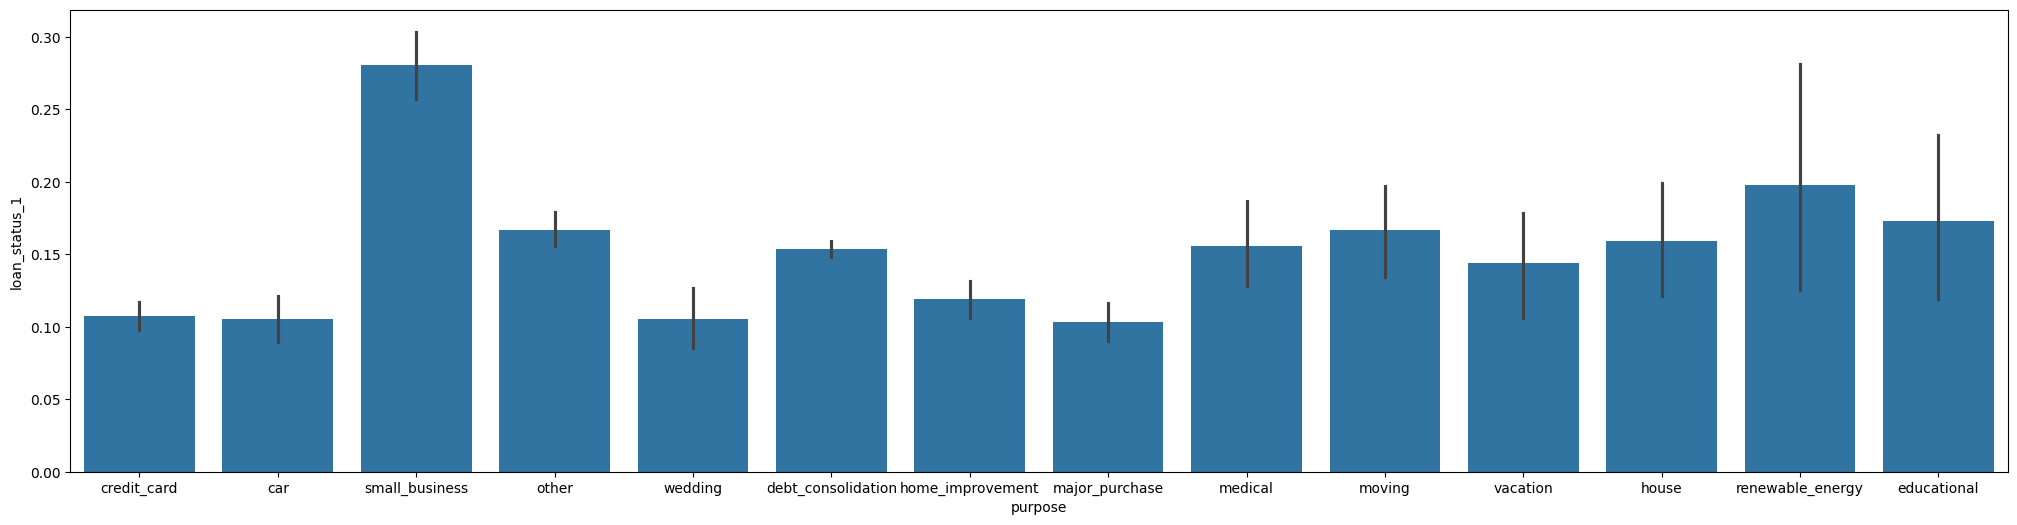

In [ ]:
plt.figure(figsize = (25,6))
plot_cat('purpose')

This chart shows that which purpose of loans get more default.The small businesses become more defaulters as they have a high amount of risk for earning the profit.

In [ ]:
df['issue_d_1'] = pd.to_datetime(df['issue_d'] , format = '%b-%y')
df['month'] = df['issue_d_1'].dt.month
df['year'] = df['issue_d_1'].dt.year
df.groupby('year').year.count()

,year
year,
2009,2786
2010,11532
2011,20516


Changing the format of issued date

In [ ]:
df.groupby('month').month.count()

,month
month,
1,1969
2,1924
3,2179
4,2386
5,2529
6,2757
7,3048
8,3284
9,3448


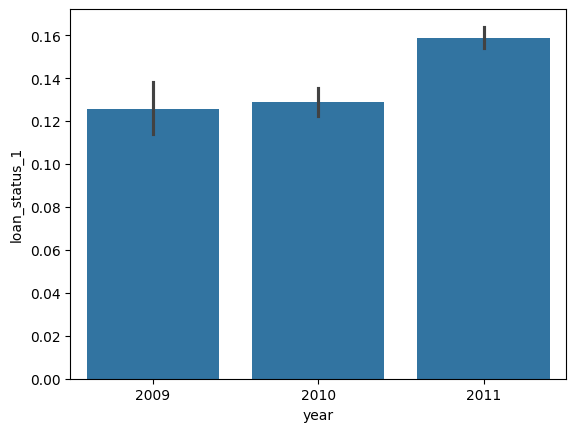

In [ ]:
plot_cat('year')

This chart shows that in which year the most amount of defaulters has happened.The reason that can be is that the most amount of loan is given in 2011.

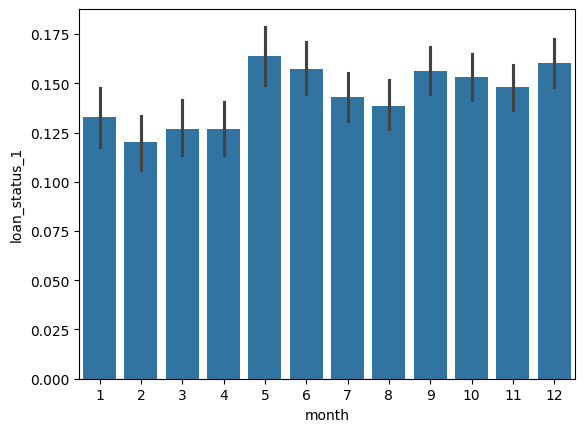

In [ ]:
plot_cat('month')

This shows that in which month the most amount of defaulters has happened.

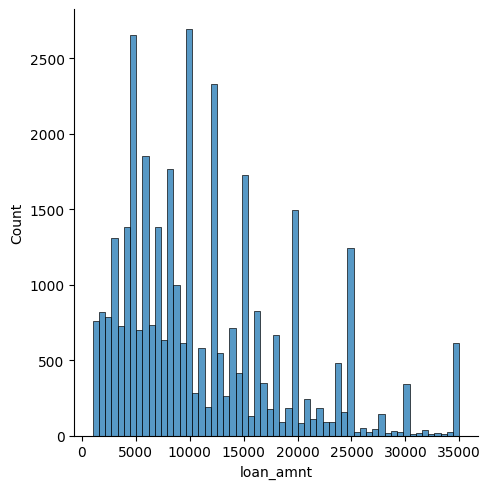

In [ ]:
sns.displot(df['loan_amnt'])
plt.show()

This chart shows that what is the amount of loan given to number of people.

In [ ]:
def loan_amount(n):
    if n < 5000:
        return 'low'
    elif n < 15000:
        return 'medium'
    elif n < 25000:
        return 'high'
    else:
        return 'very high'

df['loan_amnt_1'] = loan['loan_amnt'].apply(loan_amount)

In [ ]:
df['loan_amnt_1'].value_counts()

,count
loan_amnt_1,
medium,18461
high,7064
low,6644
very high,2665


It categorizes the amount of loan given.

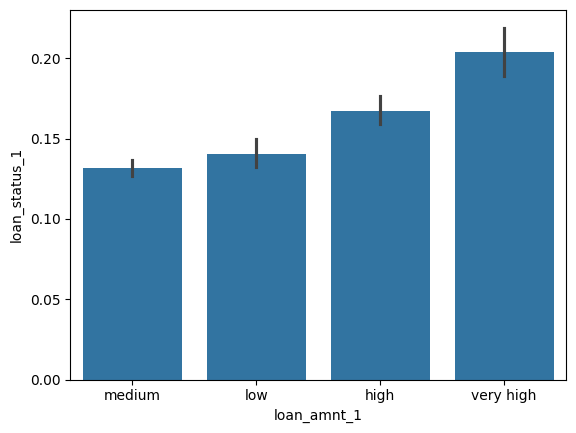

In [ ]:
plot_cat('loan_amnt_1')

In [ ]:
df['funded_amnt_inv_1'] = loan['funded_amnt_inv'].apply(loan_amount)

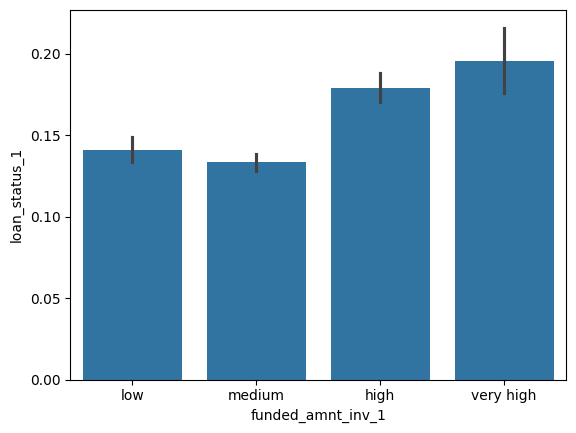

In [ ]:
plot_cat('funded_amnt_inv_1')

In [ ]:
def int_rate_1(n):
  if n<=10:
    return('low')
  elif n > 10 and n <=15:
    return('medium')
  else:
    return('high')

df['int_rate_2'] = df['int_rate_1'].apply(int_rate_1)

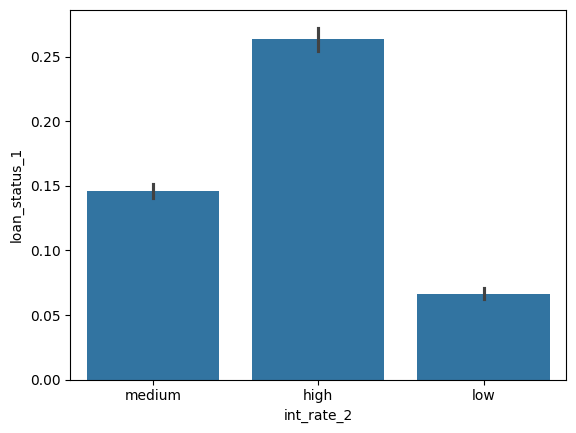

In [ ]:
plot_cat('int_rate_2')

In [ ]:
def dti(n):
  if n <= 10:
    return('low')
  elif n > 10 and n <= 20:
    return('medium')
  else:
    return('high')

df['dti_1'] = df['dti'].apply(dti)

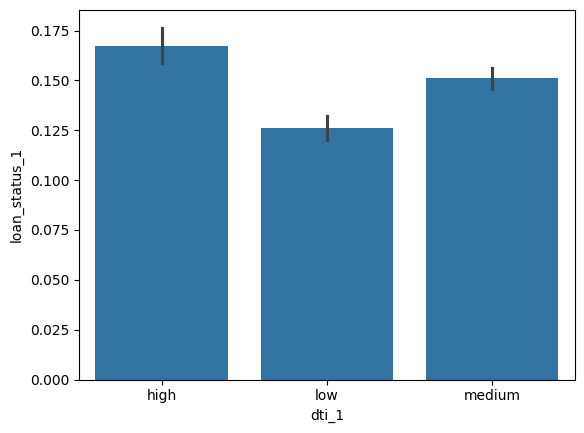

In [ ]:
plot_cat('dti_1')

In [ ]:
def funded_amount(n):
  if n <= 5000:
    return('low')
  elif n > 5000 and n <= 15000:
    return('medium')
  else:
    return('high')

df['funded_amnt_1'] = df['funded_amnt'].apply(funded_amount)

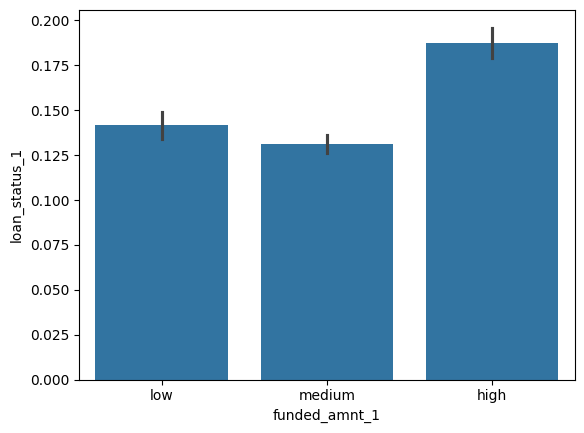

In [ ]:
plot_cat('funded_amnt_1')

In [ ]:
def installment(n):
  if n <= 200:
    return('low')
  elif n > 200 and n <= 400:
    return('medium')
  elif n > 400 and n <= 600:
    return('high')
  else:
    return('Very high')

df['installment_1'] = df['installment'].apply(installment)

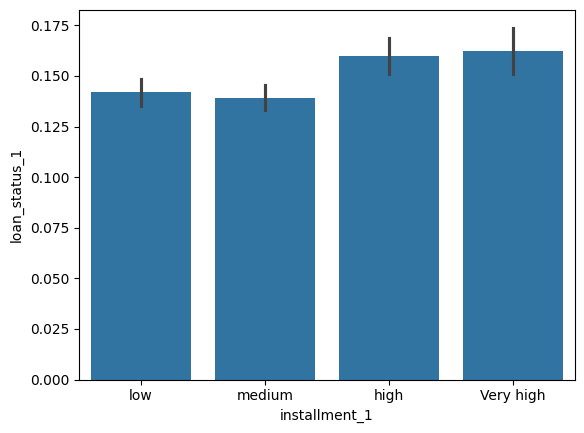

In [ ]:
plot_cat('installment_1')

In [ ]:
def annual_income(n):
  if n <= 50000:
    return('low')
  elif n > 50000 and n <= 100000:
    return('medium')
  elif n > 100000 and n <= 150000:
    return('high')
  else:
    return('Very high')

df['annual_income_1'] = df['annual_inc'].apply(annual_income)

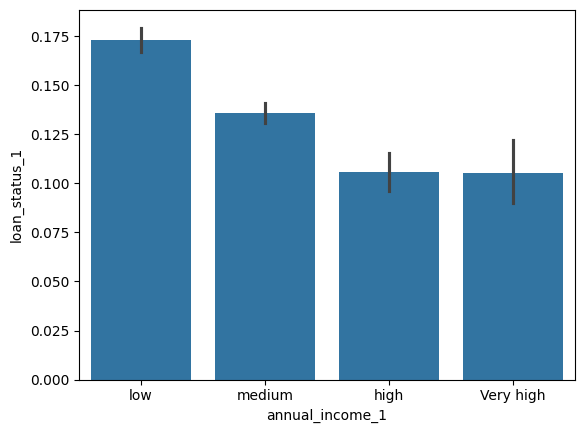

In [ ]:
plot_cat('annual_income_1')

In [ ]:
df = df[~df['emp_length_1'].isnull()]

In [ ]:
def emp_length(n):
  n = int(n)
  if n <= 1:
    return('freshers')
  elif n > 1 and n <= 3:
    return('juniors')
  elif n > 3 and n <= 7:
    return('seniors')
  else:
    return('expert')

df['emp_length_2'] = df['emp_length_1'].apply(emp_length)

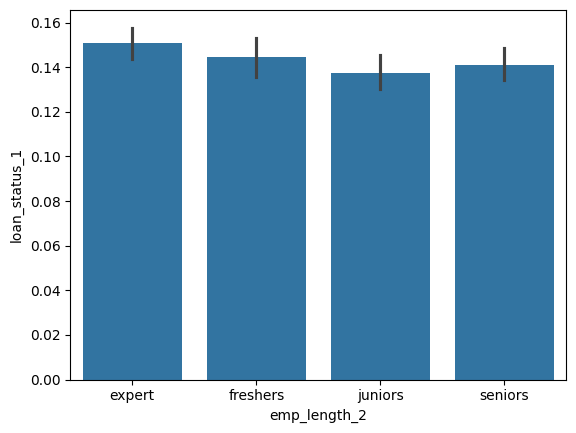

In [ ]:
plot_cat('emp_length_2')

# ***Segmented Univariate Analysis***

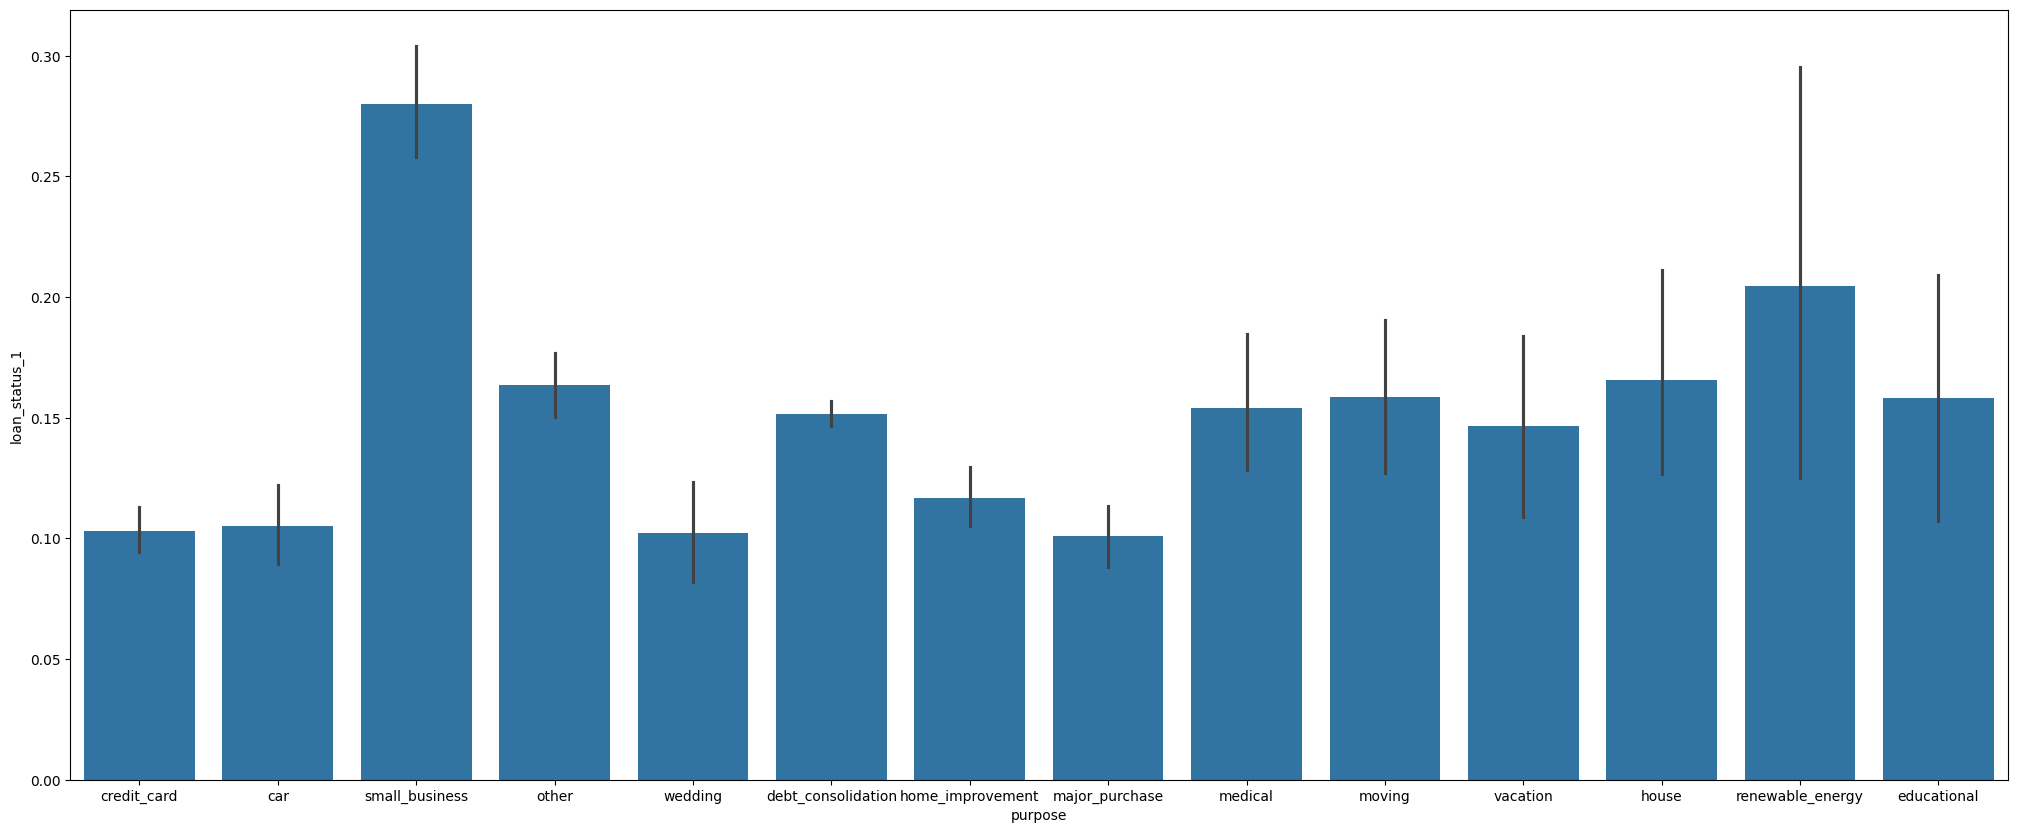

In [ ]:
plt.figure(figsize = (25,10))
plot_cat('purpose')

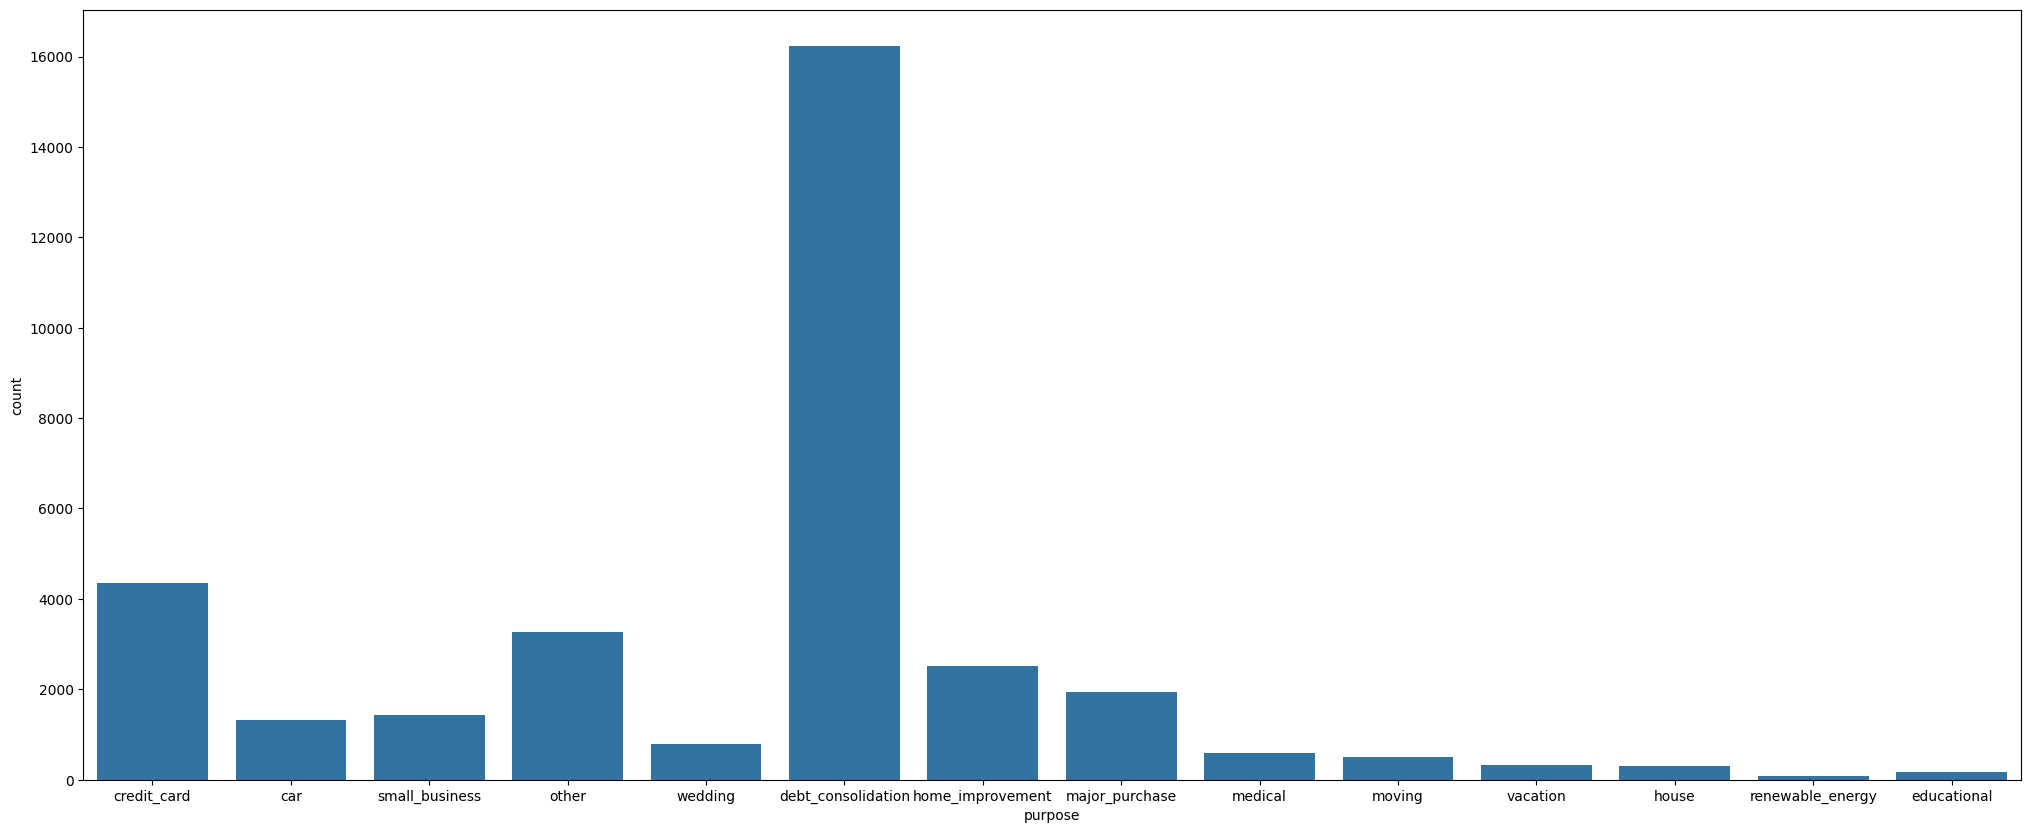

In [ ]:
plt.figure(figsize = (25,10))
sns.countplot(x = 'purpose', data = df)
plt.show()

In [ ]:
main_purpose = ['credit_card','debt_consolidation','home_improvement','major_purchase']
df = df[df['purpose'].isin(main_purpose)]
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,16227
credit_card,4354
home_improvement,2516
major_purchase,1940


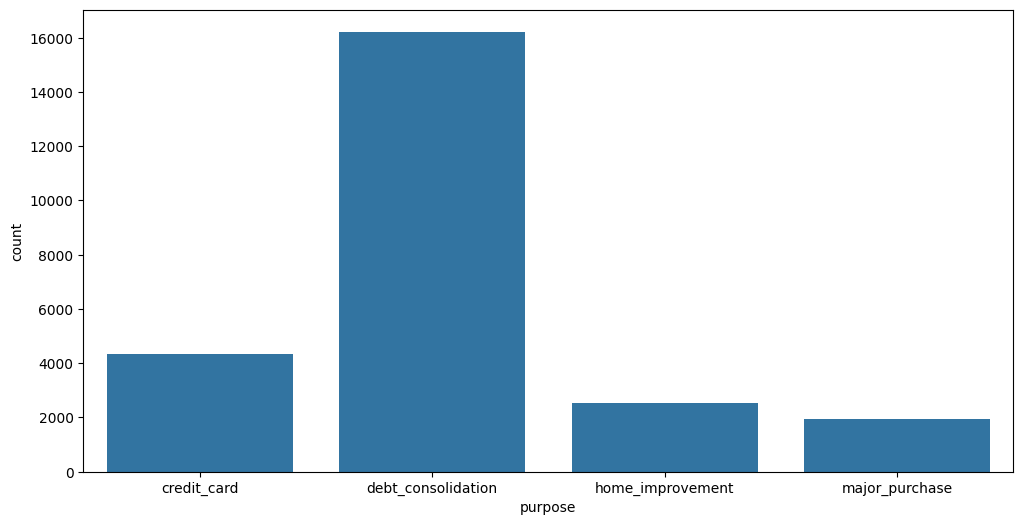

In [ ]:
plt.figure(figsize = (12,6))
sns.countplot(x = df['purpose'])
plt.show()

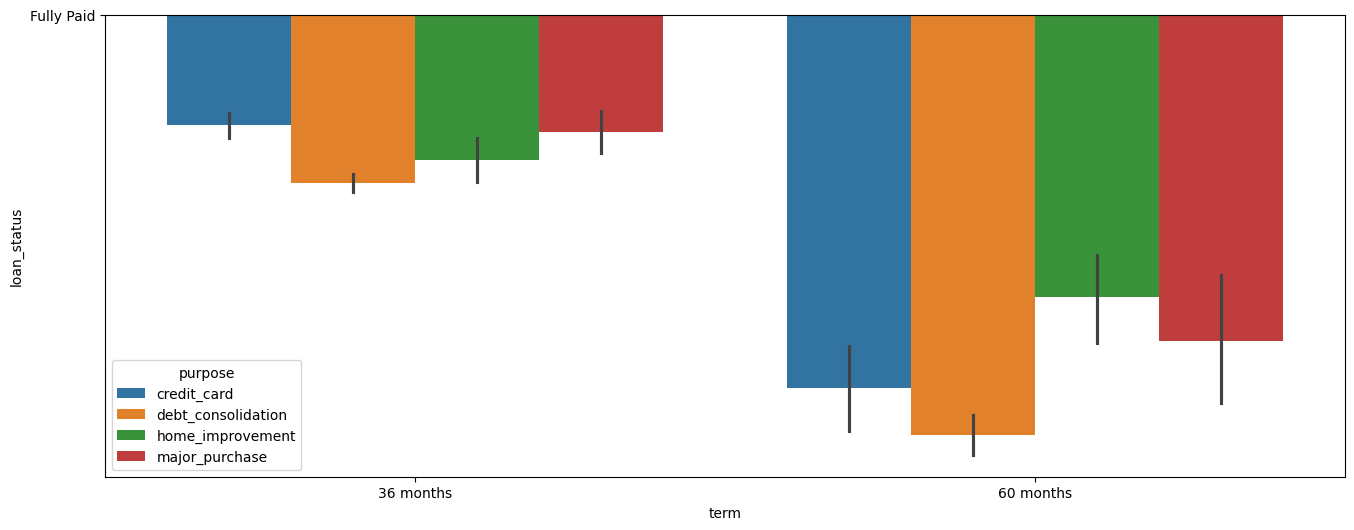

In [ ]:
plt.figure(figsize = (16,6))
sns.barplot(x = 'term',y = 'loan_status', hue = 'purpose',data = df)
plt.show()

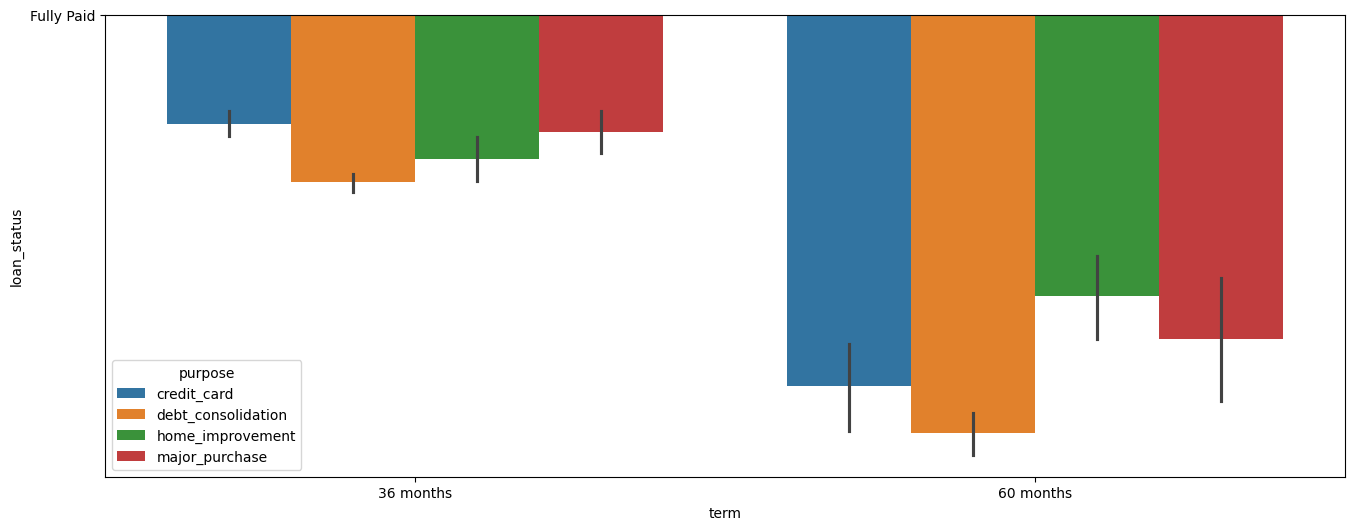

In [ ]:
def plot_segmented(cat_var):
  plt.figure(figsize = (16,6))
  sns.barplot(x = cat_var,y = 'loan_status', hue = 'purpose',data = df)
  plt.show()


plot_segmented('term')

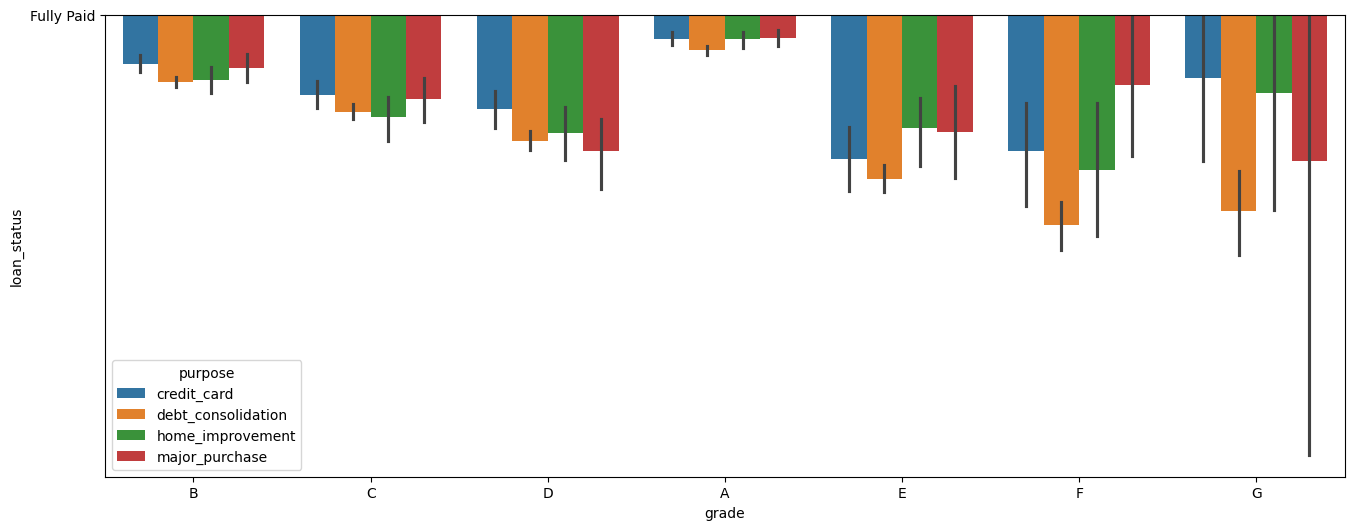

In [ ]:
plot_segmented('grade')

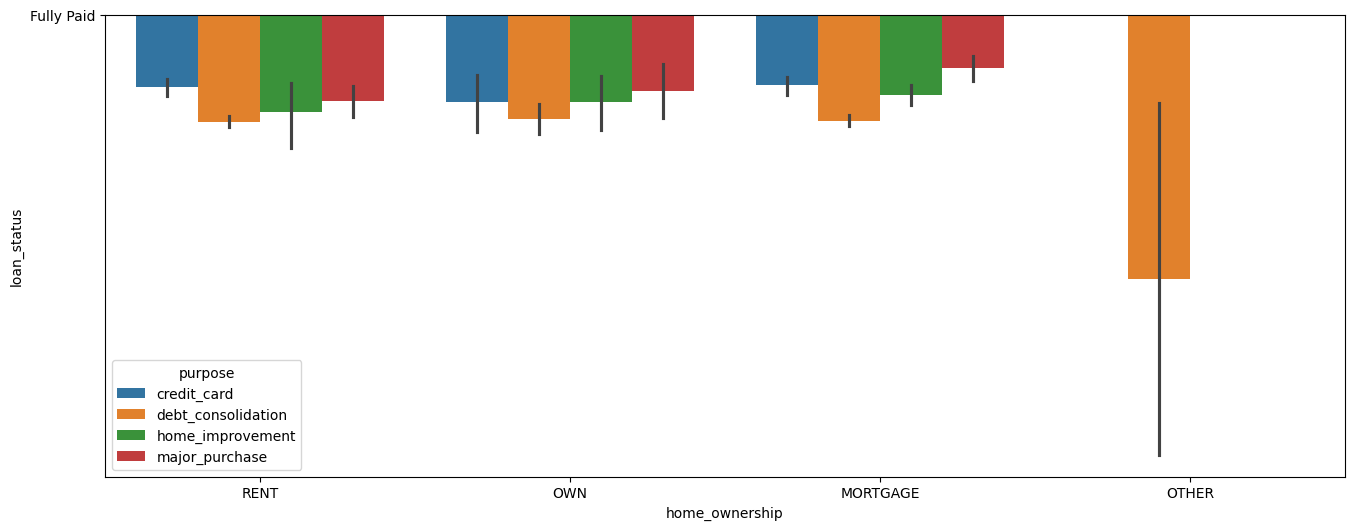

In [ ]:
plot_segmented('home_ownership')

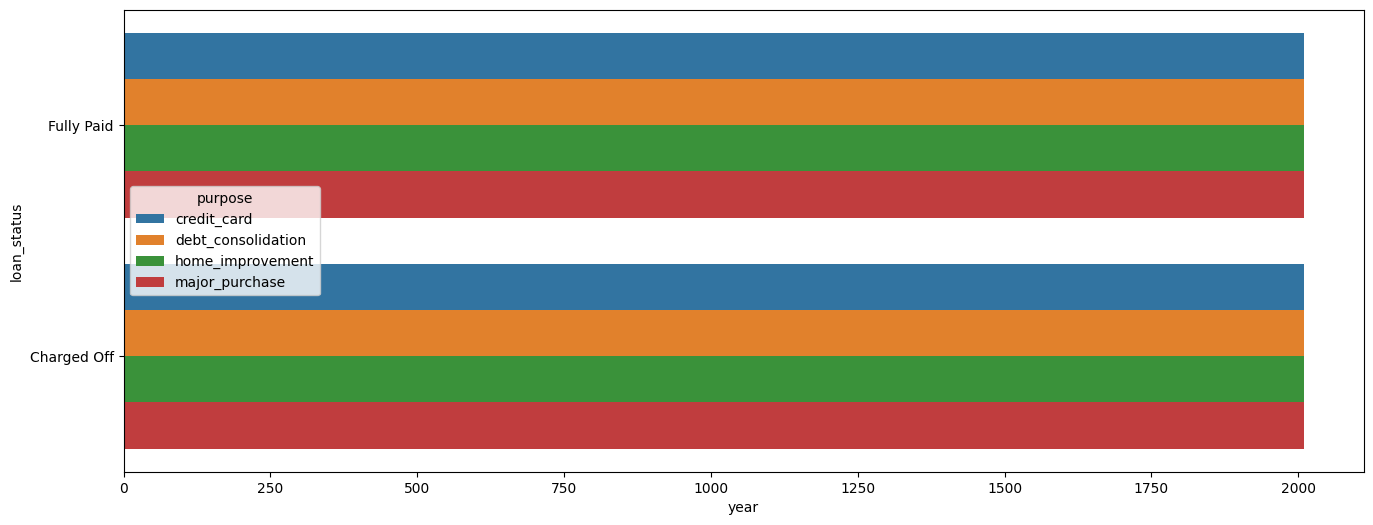

In [ ]:
plot_segmented('year')

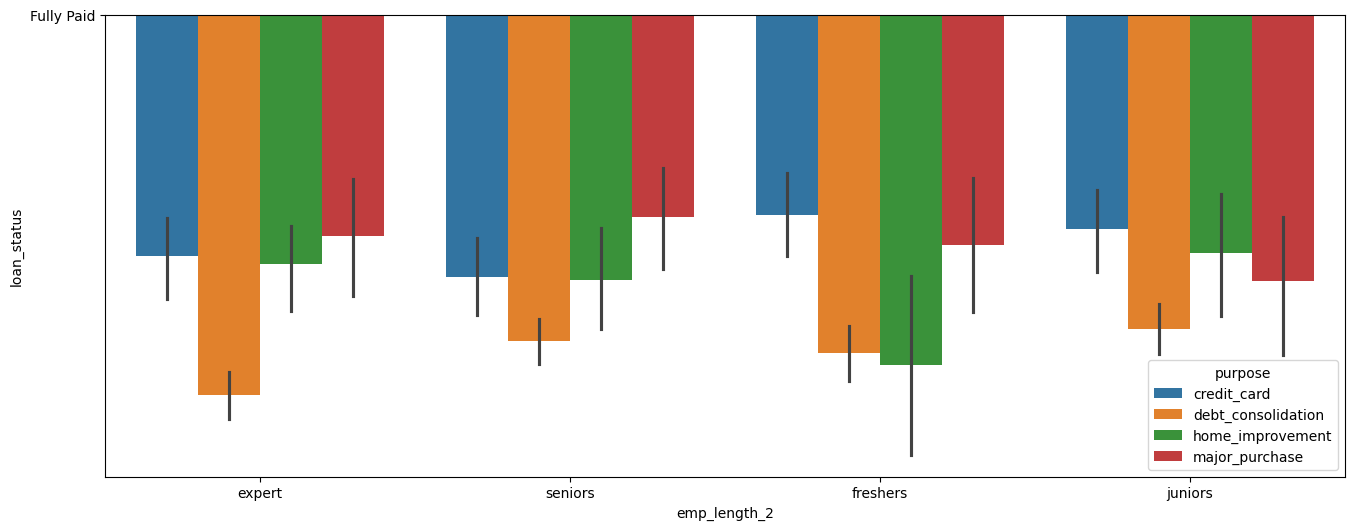

In [ ]:

plot_segmented('emp_length_2')

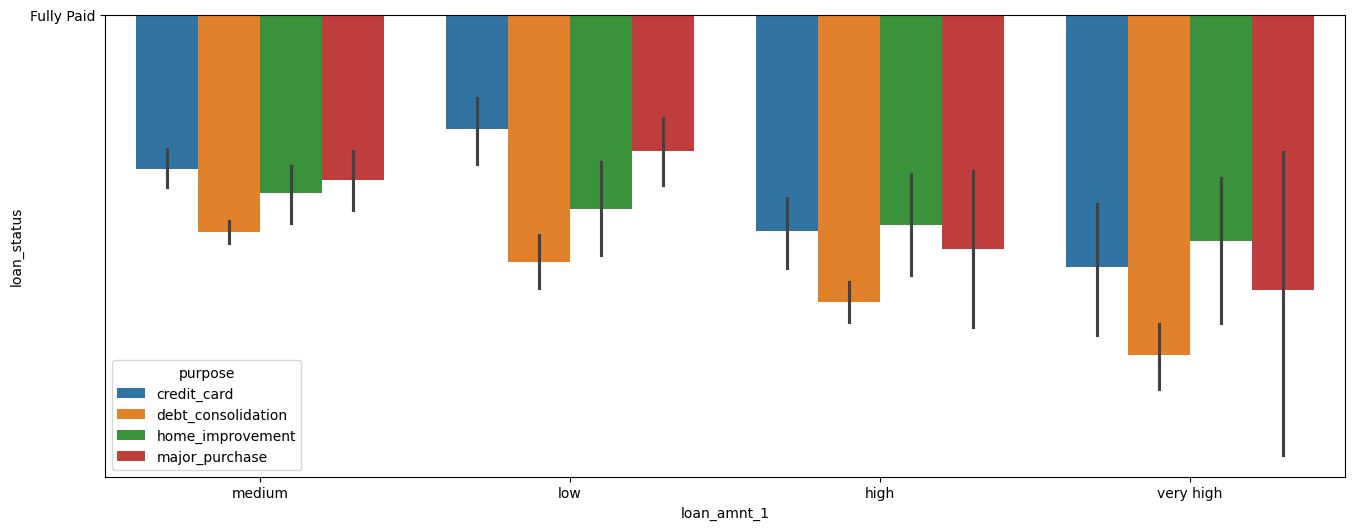

In [ ]:
plot_segmented('loan_amnt_1')

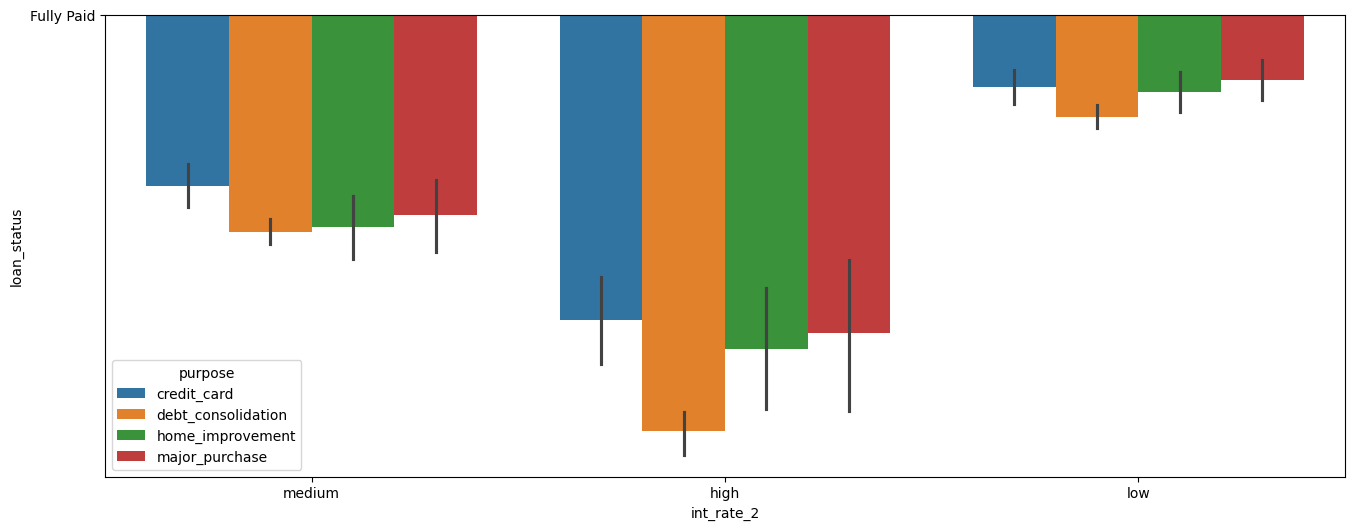

In [ ]:
plot_segmented('int_rate_2')

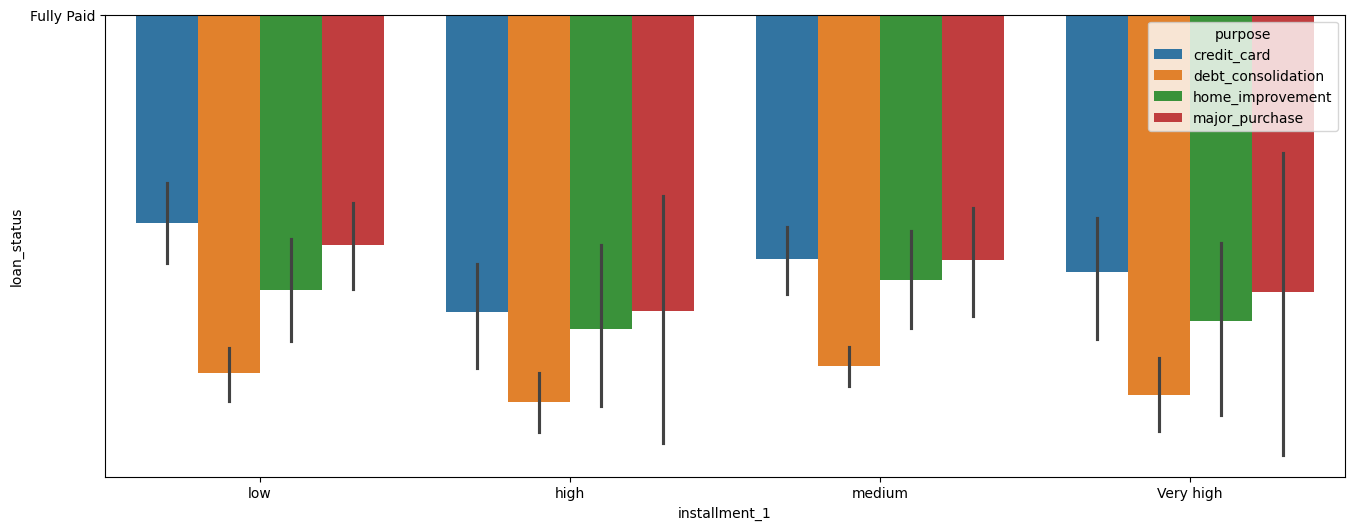

In [ ]:
plot_segmented('installment_1')

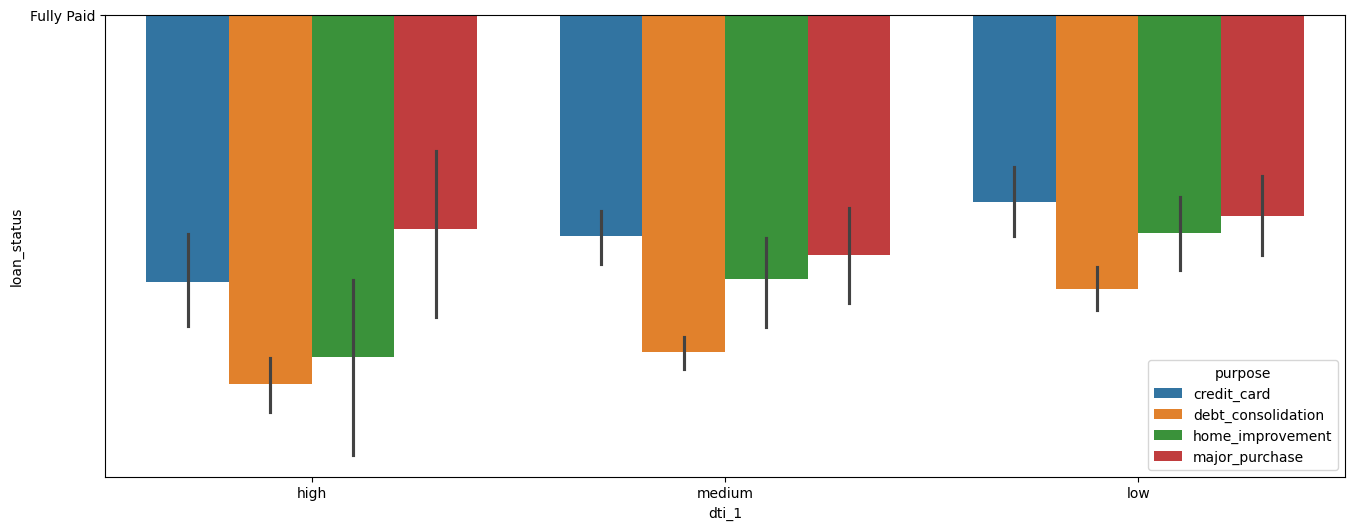

In [ ]:
plot_segmented('dti_1')

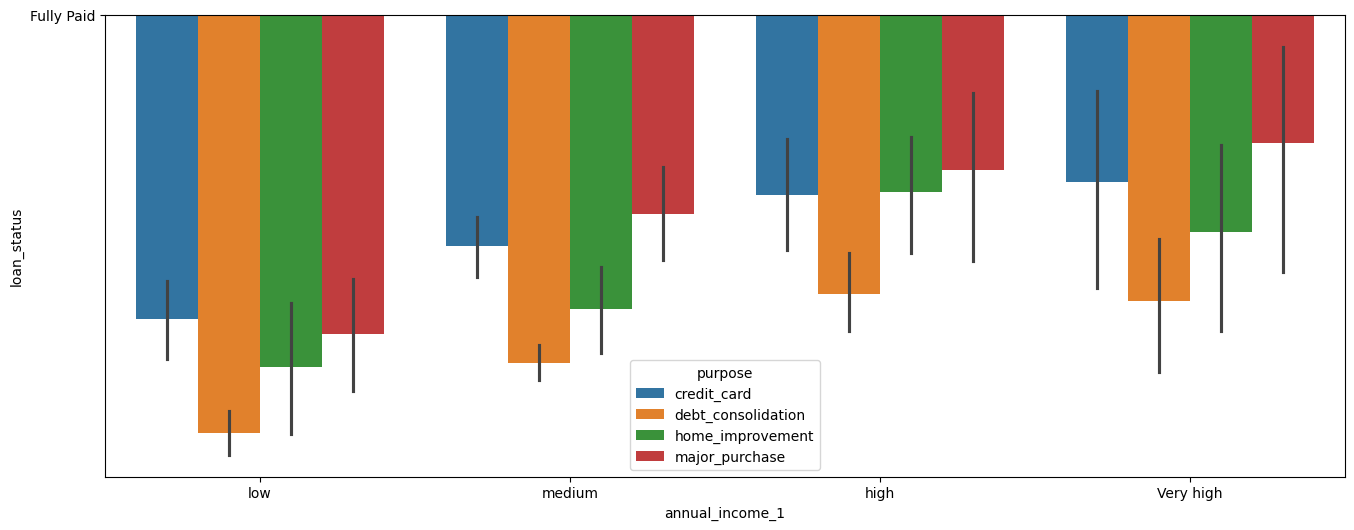

In [ ]:
plot_segmented('annual_income_1')